# 05 · 施設間シフトの特徴空間分解（実験 A）

ドメインシフトが**特徴空間のどこに入っているか**を、エンコーダごとに分解する。
現行アーキテクチャは late fusion で融合後の単一表現が無いので、5 つのエンコーダ
（T1 / T2 / FLAIR / T1c / unified）それぞれの CLS 特徴（ヘッド直前, 384 次元）について

$$\Delta = \overline{f_{\text{test}}} - \overline{f_{\text{val}}} \in \mathbb{R}^{384}$$

を、evidence ヘッド $\mathrm{Linear}(384 \to 2)$ の機能的部分空間 $\mathrm{span}\{W_1, W_0\}$ に射影する：

- $u_p = (W_1 - W_0)/\|W_1 - W_0\|$ … 判別方向（$\hat p$ を動かす）
- $u_s = \mathrm{orth}(W_1 + W_0; u_p)$ を正規化 … 確信方向（$S$ を動かす）
- $\Delta_p = \langle\Delta, u_p\rangle$（criterion シフト）, $\Delta_s = \langle\Delta, u_s\rangle$（evidence 総量シフト）,
  $\Delta_{\text{null}} = \|\Delta - \Delta_p u_p - \Delta_s u_s\|$（ヘッドから不可視な移動）

**スケール正規化**：384 次元では直交成分のノルムが自明に大きい。$d_p = \Delta_p/\sigma_p$, $d_s = \Delta_s/\sigma_s$
（$\sigma$ は val 特徴の各方向への射影の標準偏差）、$\Delta_{\text{null}}$ は「val を半分に割った null Δ の残差ノルム」
（ブートストラップ 100 回）を雑音床としてその何倍かで報告する。雑音床は raw（仕様どおり、val の半分同士なので保守的）と
size-matched（$\sqrt{(1/n_{\text{val}} + 1/n_{\text{test}})/(2/\text{half})}$ を掛けて実際の Δ と同じ標本サイズに揃えたもの）の両方を出す。

**機能への翻訳**（一次近似、softplus の局所勾配は無視）：エンコーダ $i$ の融合ロジットへの寄与シフト $\delta z_i \approx \langle\Delta, W_1 - W_0\rangle$、
evidence 総量シフト $\approx \langle\Delta, W_1 + W_0\rangle$。特徴を保存してあるので、softplus を通した**厳密な**ヘッド出力の変化も併記する。

ロジックは `openidh_model/eval/{features,shift_decomp,shift_report}.py`。特徴は `scripts/dump_features.py`
（HPC: `qsub qsub/dump_features.sh`）が `runs/<run>/features_{val,test}.npz` + `head_weights.npz` に保存済みで、
この notebook は**推論なし**で再実行できる。ヘッドの行対応（row 0 = e1/Mut, row 1 = e0/WT）は dump 時に全症例で
手計算 evidence と照合し、さらに 1 症例の融合 α/β を predictions.csv と照合してある（`features_meta.json`）。

In [1]:
import os, sys, json
from pathlib import Path
_root = Path.cwd()
while not (_root / "data" / "metadata").exists():
    _root = _root.parent
os.chdir(_root); sys.path.insert(0, str(_root))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 40)
from openidh_model.eval.features import ENCODERS
from openidh_model.eval import shift_report as sr

/workspace/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Parameters (papermill injects overrides here).
runs_dir    = "runs"
units       = ["foldA", "foldB", "field", "vendor"]   # 4 units x seeds = the 12 shift runs
seeds       = [0, 1, 2]
control_run = "rand0_s0"                             # in-distribution negative control (1 run)
n_boot      = 100                                    # half-split draws for the noise floor
boot_seed   = 0
out_json    = "results/shift_decomposition.json"
out_md      = "results/shift_decomposition.md"
fig_path    = "results/figures/shift_decomposition_heatmap.png"

## 0. 対象ランと検算ログ

各ランの `features_meta.json`（dump 時のヘッド再計算誤差と、predictions.csv との融合 α/β 照合）を確認する。
特徴の無いランはここで明示し、以降の解析はあるものだけで進める。

In [3]:
runs = [f"{u}_s{s}" for u in units for s in seeds] + ([control_run] if control_run else [])
present = [r for r in runs if sr.load_run(runs_dir, r) is not None]
missing = [r for r in runs if r not in present]
print(f"{len(present)}/{len(runs)} runs have feature dumps")
if missing:
    print("MISSING (no features_*.npz / head_weights.npz — run scripts/dump_features.py where the checkpoints are):")
    print("  " + " ".join(missing))
rows = []
for r in present:
    m = json.loads((Path(runs_dir) / r / "features_meta.json").read_text())
    for role in ("val", "test"):
        c = m["checks"][role]
        rows.append({"run": r, "role": role, "n": m[f"n_{role}"],
                     "head_rel_err": max(c["rel_err"].values()),
                     "head_rel_err_rows_swapped": min(c["rel_err_swapped"].values()), "fused_check": c["fused"]})
checks = pd.DataFrame(rows)
# stored row order reproduces the model (TF32 on the cluster -> ~1e-3); swapped rows must not
assert (checks["head_rel_err"] < 1e-2).all(), "head recomputation mismatch"
assert (checks["head_rel_err_rows_swapped"] > 100 * checks["head_rel_err"]).all(), "row order not separable"
display(checks)

13/13 runs have feature dumps


,run,role,n,head_rel_err,head_rel_err_rows_swapped,fused_check
0,foldA_s0,val,227,0.000527,14.598562,"BT0007: alpha 36.3982 vs csv 36.3982, beta 1.9..."
1,foldA_s0,test,501,0.000612,13.254355,"UCSF-PDGM-004: alpha 1.4114 vs csv 1.4114, bet..."
2,foldA_s1,val,227,0.000585,13.645400,"BT0007: alpha 30.4761 vs csv 30.4761, beta 1.7..."
3,foldA_s1,test,501,0.000467,13.460176,"UCSF-PDGM-004: alpha 1.3296 vs csv 1.3296, bet..."
4,foldA_s2,val,227,0.000582,12.167316,"BT0007: alpha 35.6176 vs csv 35.6176, beta 1.6..."
5,foldA_s2,test,501,0.000665,11.279823,"UCSF-PDGM-004: alpha 1.5584 vs csv 1.5584, bet..."
6,foldB_s0,val,204,0.000404,11.612530,"UCSF-PDGM-007: alpha 1.5158 vs csv 1.5158, bet..."
7,foldB_s0,test,619,0.000442,11.068301,"BT0001: alpha 1.6058 vs csv 1.6058, beta 41.29..."
8,foldB_s1,val,204,0.000532,14.495152,"UCSF-PDGM-007: alpha 1.3865 vs csv 1.3865, bet..."
9,foldB_s1,test,619,0.000771,14.553437,"BT0001: alpha 1.5297 vs csv 1.5297, beta 41.70..."


## 1. 分解表：ラン × エンコーダ × {d_p, d_s, Δ_null/雑音床}

3 seed の平均 ± sd。`se_d` は標準化平均差の解析的標準誤差 $\sqrt{1/n_{\text{val}}+1/n_{\text{test}}}$（d_p, d_s の雑音の目安）。

In [4]:
df, _ = sr.decompose_all(runs_dir, present, n_boot=n_boot, seed=boot_seed)
summ = sr.summarize_units(df)
per_run_cols = ["run", "unit", "enc", "n_val", "n_test", "d_p", "d_s", "se_d", "null_over_floor",
                "null_over_floor_matched", "dz_lin", "dS_lin", "dS_exact", "dS_exact_rel", "cos_sum_diff"]
display(df[per_run_cols].round(3))
print(sr.table_markdown(summ))

,run,unit,enc,n_val,n_test,d_p,d_s,se_d,null_over_floor,null_over_floor_matched,dz_lin,dS_lin,dS_exact,dS_exact_rel,cos_sum_diff
0,foldA_s0,LOSO-A,T1,227,501,-0.119,0.044,0.080,1.490,2.478,-1.241,0.109,-0.188,-0.021,-0.015
1,foldA_s0,LOSO-A,T2,227,501,-0.375,-0.194,0.080,3.430,5.703,-4.584,-0.394,0.782,0.060,-0.007
2,foldA_s0,LOSO-A,FLAIR,227,501,0.205,-0.166,0.080,5.487,9.124,2.011,-0.427,-1.742,-0.252,0.017
3,foldA_s0,LOSO-A,T1c,227,501,-0.122,-0.221,0.080,2.056,3.419,-1.646,-0.594,-0.283,-0.022,0.073
4,foldA_s0,LOSO-A,unified,227,501,0.075,-0.311,0.080,2.495,4.148,0.910,-1.914,-1.610,-0.215,-0.010
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60,rand0_s0,random f0,T1,262,327,0.096,-0.173,0.083,0.755,1.125,0.928,-0.326,-0.188,-0.030,-0.010
61,rand0_s0,random f0,T2,262,327,-0.077,-0.034,0.083,0.587,0.874,-0.737,-0.074,-0.168,-0.052,-0.014
62,rand0_s0,random f0,FLAIR,262,327,-0.011,-0.037,0.083,0.522,0.778,-0.114,-0.063,-0.038,-0.006,0.023
63,rand0_s0,random f0,T1c,262,327,0.087,0.037,0.083,0.805,1.199,1.225,0.207,-0.243,-0.022,0.076


| ユニット | enc | d_p (σ) | d_s (σ) | Δ_null / 雑音床 (raw) | Δ_null / 雑音床 (size-matched) | n_seed |
|---|---|---|---|---|---|---|
| LOSO-A | T1 | -0.01 ± 0.14 | +0.04 ± 0.08 | 1.56 ± 0.07 | 2.59 ± 0.11 | 3 |
| LOSO-A | T2 | -0.34 ± 0.03 | +0.13 ± 0.29 | 3.46 ± 0.24 | 5.76 ± 0.41 | 3 |
| LOSO-A | FLAIR | +0.27 ± 0.08 | -0.17 ± 0.21 | 5.70 ± 0.99 | 9.48 ± 1.65 | 3 |
| LOSO-A | T1c | -0.12 ± 0.07 | -0.23 ± 0.05 | 2.00 ± 0.26 | 3.32 ± 0.44 | 3 |
| LOSO-A | unified | +0.10 ± 0.26 | -0.14 ± 0.15 | 2.58 ± 0.48 | 4.29 ± 0.80 | 3 |
| LOSO-B | T1 | +0.23 ± 0.13 | -0.28 ± 0.17 | 1.85 ± 0.14 | 3.22 ± 0.25 | 3 |
| LOSO-B | T2 | -0.11 ± 0.11 | +0.08 ± 0.14 | 2.18 ± 0.17 | 3.78 ± 0.29 | 3 |
| LOSO-B | FLAIR | -0.19 ± 0.21 | +0.15 ± 0.33 | 1.69 ± 0.18 | 2.93 ± 0.32 | 3 |
| LOSO-B | T1c | +0.49 ± 0.03 | -0.14 ± 0.38 | 2.76 ± 0.62 | 4.79 ± 1.08 | 3 |
| LOSO-B | unified | +0.05 ± 0.17 | -0.09 ± 0.23 | 1.58 ± 0.60 | 2.74 ± 1.04 | 3 |
| field 3T | T1 | -0.17 ± 0.07 | +0.14 ± 0.17 | 0.88 ± 0.16 | 1.47 ± 0.26 | 3

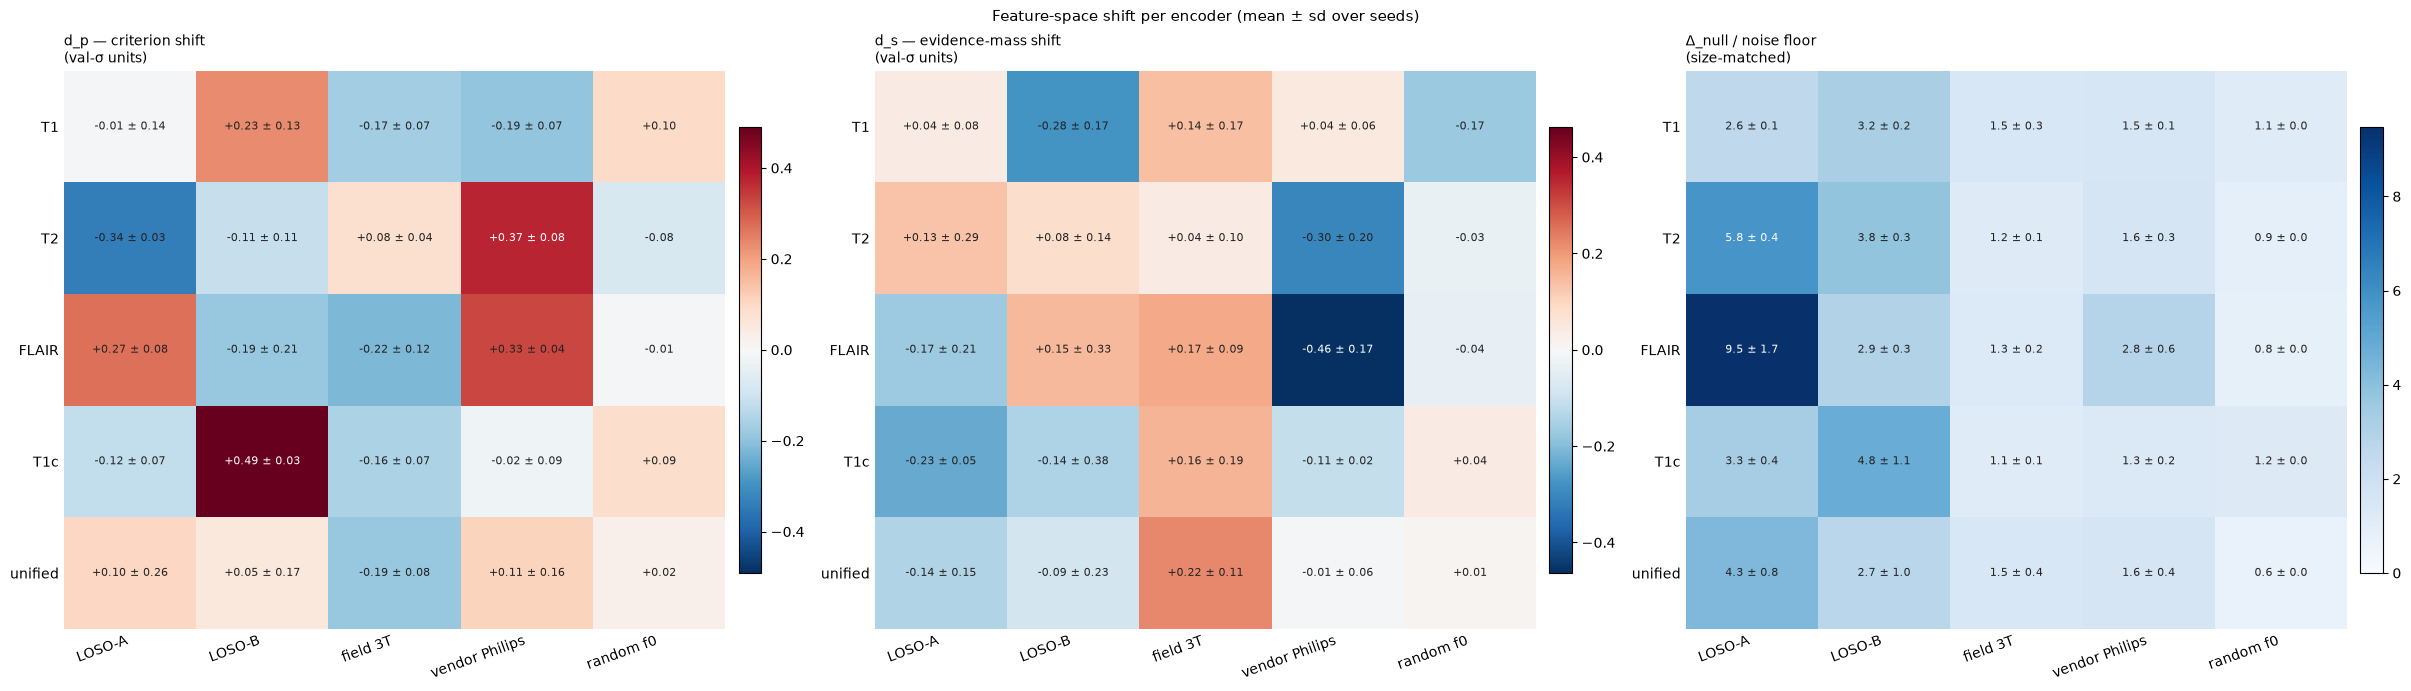

In [5]:
fig = sr.heatmap(summ, fig_path, title="Feature-space shift per encoder (mean ± sd over seeds)")
plt.show()

## 2. ユニット間比較（本丸）

- **field / vendor** は train・val・test がすべて UTSW で有病率シフトがほぼゼロの「1b プローブ」。ここでの Δ の入り方
  （d_p に入るか d_s に入るか）が撮像由来シフトの正体。
- **LOSO-A / LOSO-B** は 1a（症例構成）+ 1b（撮像）の混合。field/vendor のパターンとの差分が 1a の寄与の示唆。
- **random f0** は分布内の陰性対照：全成分が雑音床近傍のはず。

判定はユニットごとに、各成分を自分の雑音床（d_p, d_s は se_d、Δ_null は size-matched 雑音床）で割った比を
エンコーダ平均し、2 倍を超えるものを「動いた」とみなす（`sr.judge_unit`）。

In [6]:
unit_labels = [u for u in sr.UNIT_ORDER if u in set(summ["unit"])] + \
              [u for u in summ["unit"].unique() if u not in sr.UNIT_ORDER]
verdicts = {u: sr.judge_unit(summ, u) for u in unit_labels}
vt = pd.DataFrame([{"unit": u, **{f"{k}/floor": round(v, 2) for k, v in d["ratios"].items()},
                    "verdict": d["verdict"]} for u, d in verdicts.items()])
display(vt)

# per-unit, per-encoder view of where the mass is: |d_p| vs |d_s| (both in val-σ units)
piv = summ.pivot(index="enc", columns="unit", values=["d_p_mean", "d_s_mean", "null_over_floor_matched_mean"]).round(2)
display(piv)

,unit,d_p/floor,d_s/floor,delta_null/floor,verdict
0,LOSO-A,2.10,1.78,5.09,delta_null dominant
1,LOSO-B,2.66,1.83,3.49,delta_null dominant
2,field 3T,1.25,1.13,1.31,no component clears 2x its floor on the encode...
3,vendor Philips,1.54,1.40,1.77,no component clears 2x its floor on the encode...
4,random f0,0.71,0.71,0.92,no component clears 2x its floor on the encode...


d_p_mean                                          d_s_mean                                          null_over_floor_matched_mean                                         
unit      LOSO-A LOSO-B field 3T vendor Philips random f0   LOSO-A LOSO-B field 3T vendor Philips random f0                       LOSO-A LOSO-B field 3T vendor Philips random f0
enc                                                                                                                                                                              
T1         -0.01   0.23    -0.17          -0.19      0.10     0.04  -0.28     0.14           0.04     -0.17                         2.59   3.22     1.47           1.49      1.13
T2         -0.34  -0.11     0.08           0.37     -0.08     0.13   0.08     0.04          -0.30     -0.03                         5.76   3.78     1.18           1.60      0.87
FLAIR       0.27  -0.19    -0.22           0.33     -0.01    -0.17   0.15     0.17          -0.46     -0.04                         9.48   2.93     1.28           2.83      0.78
T1c        -0.12   0.49    -0.16          -0.02      0.09    -0.23  -0.14     0.16          -0.11      0.04                         3.32   4.79     1.14           1.33      1.20
unified     0.10   0.05    -0.19           0.11      0.02    -0.14  -0.09     0.22          -0.01      0.01                         4.29   2.74     1.47           1.58      0.64

## 3. 層別 Δ による 1a / 1b の直接分離（LOSO のみ）

(grade 二値 × 年齢 3 区分) の層ごとに Δ を計算し、Kitagawa 分解

$$\Delta = \underbrace{\sum_k \pi^{\text{test}}_k(\mu^{\text{test}}_k - \mu^{\text{val}}_k)}_{\text{層内 } \approx \text{撮像由来 (1b)}}
+ \underbrace{\sum_k (\pi^{\text{test}}_k - \pi^{\text{val}}_k)\,\mu^{\text{val}}_k}_{\text{症例構成由来 (1a)}}$$

で、全体 Δ − 症例数（test 側）加重平均の層内 Δ ≈ 症例構成由来の成分、とする。ラベルは使わない（age / grade のみ、
既存の較正解析と同じ共変量）。層は両側に 3 例以上あるものだけを使い、test 側のカバー率を併記する。
UPenn は GBM コホートなので grade 4 固定（データセット定義）。各部分を $(u_p, u_s)$ に射影し val-σ 単位で示す。

In [7]:
loso_runs = [r for r in present if sr.unit_of(r)[1] in ("site", "probe")]   # LOSO first, then the probes
strat_rows = []
for r in loso_runs:
    rd = sr.load_run(runs_dir, r)
    strat_rows += sr.stratified_run(rd)
strat = pd.DataFrame(strat_rows)
if len(strat):
    strat["enc"] = pd.Categorical(strat["enc"], ENCODERS)
    for r in loso_runs[:1]:
        print(f"strata counts, {r}:"); display(sr.strata_table(sr.load_run(runs_dir, r)))
    cols = ["delta_dp", "within_dp", "composition_dp", "delta_ds", "within_ds", "composition_ds", "covered"]
    g = strat.groupby(["unit", "enc"], observed=True)[cols]
    strat_summ = pd.concat([g.mean().add_suffix("_mean"), g.std(ddof=1).fillna(0).add_suffix("_sd")], axis=1).round(2)
    display(strat_summ)
    # share of the in-plane shift that survives holding the case mix fixed
    for u in strat["unit"].unique():
        s = strat[strat.unit == u]
        for comp in ("dp", "ds"):
            tot = s[f"delta_{comp}"].abs().mean(); win = s[f"within_{comp}"].abs().mean()
            print(f"{u:8s} {comp}: |within| / |delta| = {win / tot if tot else float('nan'):.2f}  "
                  f"(mean over encoders x seeds; covered {s['covered'].mean():.2f})")
else:
    print("no LOSO run has features — analysis 3 skipped")

strata counts, foldA_s0:


,stratum,n_val,n_test,mut_val,mut_test
0,hi/a1,39,102,0.230769,0.235294
1,hi/a2,72,155,0.000000,0.019355
2,hi/a3,75,145,0.000000,0.006897
3,lo/a1,32,73,0.812500,0.904110
4,lo/a2,5,17,0.600000,0.411765
5,lo/a3,2,9,0.000000,0.222222
6,na/a1,1,0,0.000000,NaN
7,na/a3,1,0,0.000000,NaN


delta_dp_mean  within_dp_mean  composition_dp_mean  delta_ds_mean  within_ds_mean  composition_ds_mean  covered_mean  delta_dp_sd  within_dp_sd  composition_dp_sd  \
unit           enc                                                                                                                                                                           
LOSO-A         T1               -0.01           -0.04                 0.03           0.04            0.07                -0.03          0.98         0.14          0.14               0.01   
               T2               -0.34           -0.38                 0.04           0.13            0.16                -0.03          0.98         0.03          0.03               0.01   
               FLAIR             0.27            0.23                 0.04          -0.17           -0.13                -0.04          0.98         0.08          0.08               0.01   
               T1c              -0.12           -0.16                 0.04          -0.23           -0.25                 0.02          0.98         0.07          0.07               0.00   
               unified           0.10            0.05                 0.05          -0.14           -0.11                -0.03          0.98         0.26          0.26               0.00   
LOSO-B         T1                0.23           -0.02                 0.25          -0.28           -0.08                -0.20          0.97         0.13          0.15               0.02   
               T2               -0.11           -0.24                 0.13           0.08            0.30                -0.22          0.97         0.11          0.08               0.04   
               FLAIR            -0.19           -0.43                 0.24           0.15            0.34                -0.19          0.97         0.21          0.27               0.06   
               T1c               0.49            0.13                 0.36          -0.14           -0.22                 0.07          0.97         0.03          0.01               0.03   
               unified           0.05           -0.37                 0.42          -0.09            0.26                -0.35          0.97         0.17          0.13               0.06   
field 3T       T1               -0.17           -0.17                 0.00           0.14            0.14                -0.00          0.96         0.07          0.09               0.02   
               T2                0.08            0.18                -0.10           0.04           -0.05                 0.09          0.96         0.04          0.05               0.01   
               FLAIR            -0.22           -0.16                -0.06           0.17            0.17                 0.00          0.96         0.12          0.15               0.05   
               T1c              -0.16           -0.04                -0.12           0.16            0.18                -0.02          0.96         0.07          0.10               0.03   
               unified          -0.19           -0.07                -0.11           0.22            0.10                 0.13          0.96         0.08          0.08               0.03   
vendor Philips T1               -0.19           -0.11                -0.08           0.04            0.04                 0.00          0.95         0.07          0.10               0.03   
               T2                0.37            0.39                -0.02          -0.30           -0.31                 0.01          0.95         0.08          0.09               0.00   
               FLAIR             0.33            0.40                -0.07          -0.46           -0.49                 0.02          0.95         0.04          0.03               0.03   
               T1c              -0.02           -0.11                 0.09          -0.11           -0.17                 0.06          0.95         0.09          0.11               0.05   
               unified           0

LOSO-A   dp: |within| / |delta| = 1.04  (mean over encoders x seeds; covered 0.98)
LOSO-A   ds: |within| / |delta| = 1.03  (mean over encoders x seeds; covered 0.98)
LOSO-B   dp: |within| / |delta| = 1.10  (mean over encoders x seeds; covered 0.97)
LOSO-B   ds: |within| / |delta| = 1.14  (mean over encoders x seeds; covered 0.97)
field 3T dp: |within| / |delta| = 0.82  (mean over encoders x seeds; covered 0.96)
field 3T ds: |within| / |delta| = 0.83  (mean over encoders x seeds; covered 0.96)
vendor Philips dp: |within| / |delta| = 1.03  (mean over encoders x seeds; covered 0.95)
vendor Philips ds: |within| / |delta| = 1.11  (mean over encoders x seeds; covered 0.95)


## 4. vendor の evidence 崩壊の帰属

予想：vendor ランで T1 / T2 / FLAIR の d_s が大きく負、T1c は小さい。unified はどちら側か。
線形近似 $\langle\Delta, W_1+W_0\rangle$ と、特徴から softplus を通して計算した**厳密な** raw evidence 変化
（`dS_exact_rel` = test/val − 1）、および predictions.csv の**スケール後** evidence 変化（既報の「半減」）を並べる。

In [8]:
rows = []
for r in present:
    rd = sr.load_run(runs_dir, r)
    ev = sr.evidence_change_from_predictions(rd)
    for enc in ENCODERS + ["tabular"]:
        if enc in ev:
            rows.append({"run": r, "unit": sr.unit_of(r)[0], "enc": enc, **{f"scaled_{k}": v for k, v in ev[enc].items()}})
scaled = pd.DataFrame(rows)
scaled["enc"] = pd.Categorical(scaled["enc"], ENCODERS + ["tabular"])
a4 = df[["run", "unit", "enc", "d_s", "dS_lin", "dS_exact_rel", "S_val_mean", "S_test_mean"]].astype({"enc": str}).merge(
    scaled.astype({"enc": str}), on=["run", "unit", "enc"], how="left")
a4["enc"] = pd.Categorical(a4["enc"], ENCODERS)
a4_summ = a4.groupby(["unit", "enc"], observed=True)[["d_s", "dS_lin", "dS_exact_rel", "scaled_rel"]].agg(["mean", "std"]).round(3)
display(a4_summ)
# order encoders by mean d_s in the vendor unit, if present
if "vendor Philips" in set(a4["unit"]):
    v = a4[a4.unit == "vendor Philips"].groupby("enc", observed=True)[["d_s", "dS_exact_rel", "scaled_rel"]].mean().sort_values("d_s")
    print("vendor Philips — encoders ordered by d_s:"); display(v.round(3))

d_s        dS_lin        dS_exact_rel        scaled_rel       
                         mean    std   mean    std         mean    std       mean    std
unit           enc                                                                      
LOSO-A         T1       0.040  0.075  0.178  0.376       -0.047  0.023     -0.041  0.023
               T2       0.133  0.287  0.610  0.874        0.105  0.056      0.107  0.054
               FLAIR   -0.168  0.211 -0.617  0.736       -0.330  0.098     -0.328  0.099
               T1c     -0.233  0.055 -0.617  0.175       -0.039  0.021     -0.037  0.024
               unified -0.141  0.152 -0.690  1.062       -0.109  0.104     -0.106  0.104
LOSO-B         T1      -0.278  0.174 -1.038  0.923       -0.137  0.064     -0.150  0.062
               T2       0.080  0.135  0.265  0.427        0.031  0.070      0.016  0.069
               FLAIR    0.151  0.328  0.436  1.037        0.081  0.155      0.069  0.152
               T1c     -0.144  0.381 -0.180  1.388       -0.134  0.065     -0.141  0.066
               unified -0.087  0.231 -0.379  1.018       -0.072  0.114     -0.080  0.112
field 3T       T1       0.141  0.169  0.297  0.437        0.163  0.168      0.174  0.169
               T2       0.038  0.104  0.080  0.283       -0.013  0.046     -0.011  0.048
               FLAIR    0.174  0.088  0.374  0.072        0.069  0.028      0.075  0.030
               T1c      0.159  0.188  0.347  0.317        0.058  0.042      0.065  0.040
               unified  0.223  0.114  0.722  0.433        0.128  0.075      0.128  0.081
random f0      T1      -0.173    NaN -0.326    NaN       -0.030    NaN     -0.029    NaN
               T2      -0.034    NaN -0.074    NaN       -0.052    NaN     -0.045    NaN
               FLAIR   -0.037    NaN -0.063    NaN       -0.006    NaN     -0.010    NaN
               T1c      0.037    NaN  0.207    NaN       -0.022    NaN     -0.023    NaN
               unified  0.012    NaN  0.082    NaN       -0.001    NaN      0.001    NaN
vendor Philips T1       0.044  0.057  0.095  0.125        0.034  0.081      0.025  0.084
               T2      -0.302  0.201 -0.653  0.302       -0.200  0.168     -0.206  0.166
               FLAIR   -0.463  0.166 -1.234  0.622       -0.265  0.175     -0.271  0.177
               T1c     -0.110  0.020 -0.209  0.071        0.006  0.007      0.002  0.008
               unified -0.006  0.055  0.060  0.272       -0.007  0.031     -0.020  0.030

vendor Philips — encoders ordered by d_s:


,d_s,dS_exact_rel,scaled_rel
enc,,,
FLAIR,-0.463,-0.265,-0.271
T2,-0.302,-0.200,-0.206
T1c,-0.110,0.006,0.002
unified,-0.006,-0.007,-0.020
T1,0.044,0.034,0.025


## 5. 陰性対照

1. **random f0（分布内）**：同じ分解で全成分が雑音床近傍のはず（§1 の表と図の最終列、§2 の verdict）。
2. **検算**：$\sum_i \langle\Delta_i, W_1-W_0\rangle$（エンコーダ別ロジットシフトの一次近似の合計；体積スケール・(+1) 補正は無視）
   の符号が、実測の融合ロジット変化（predictions.csv: test 平均 − val 平均）および較正解析のオフセット
   （calibration.json `prior_offset`、LOSO-B で正）と整合するか。

In [9]:
rows = []
for r in present:
    rd = sr.load_run(runs_dir, r)
    dec = [x for x in df.to_dict("records") if x["run"] == r]
    rows.append(sr.logit_shift_check(rd, dec))
lc = pd.DataFrame(rows).drop(columns=["dz_lin_by_enc"])
display(lc.round(3))
if "random f0" in set(summ["unit"]):
    print("random f0 verdict:", verdicts["random f0"]["verdict"])
for u in lc["unit"].unique():
    s = lc[lc.unit == u]
    sgn = lambda x: "+" if x > 0 else "−"
    cols = [c for c in ("fused_logit_shift", "prior_offset") if c in s]
    print(f"{u:14s} Σδz_lin {s['dz_lin_sum'].mean():+.2f}  Σδz_exact {s['dz_exact_sum'].mean():+.2f}  " +
          "  ".join(f"{c} {s[c].mean():+.2f}" for c in cols) +
          "  | signs: " + " ".join(sgn(s[c].mean()) for c in ["dz_lin_sum"] + cols))

,run,unit,dz_lin_sum,dz_exact_sum,fused_logit_shift,prior_offset,val_base_rate,test_base_rate
0,foldA_s0,LOSO-A,-4.550,-3.221,-0.317,0.252,0.167,0.206
1,foldA_s1,LOSO-A,2.887,1.999,-0.052,0.252,0.167,0.206
2,foldA_s2,LOSO-A,-4.723,-2.710,-0.271,0.252,0.167,0.206
3,foldB_s0,LOSO-B,7.673,3.340,0.433,1.092,0.118,0.284
4,foldB_s1,LOSO-B,2.168,0.287,0.214,1.092,0.118,0.284
5,foldB_s2,LOSO-B,10.262,3.899,0.355,1.092,0.118,0.284
6,field_s0,field 3T,-8.391,-2.937,-0.318,-0.053,0.282,0.272
7,field_s1,field 3T,-4.272,-2.475,-0.236,-0.053,0.282,0.272
8,field_s2,field 3T,-8.792,-4.221,-0.436,-0.053,0.282,0.272
9,vendor_s0,vendor Philips,4.504,2.572,0.252,0.425,0.260,0.350


random f0 verdict: no component clears 2x its floor on the encoder average — see the per-encoder table before calling the features unmoved
LOSO-A         Σδz_lin -2.13  Σδz_exact -1.31  fused_logit_shift -0.21  prior_offset +0.25  | signs: − − +
LOSO-B         Σδz_lin +6.70  Σδz_exact +2.51  fused_logit_shift +0.33  prior_offset +1.09  | signs: + + +
field 3T       Σδz_lin -7.15  Σδz_exact -3.21  fused_logit_shift -0.33  prior_offset -0.05  | signs: − − −
vendor Philips Σδz_lin +3.97  Σδz_exact +2.14  fused_logit_shift +0.20  prior_offset +0.42  | signs: + + +
random f0      Σδz_lin +1.48  Σδz_exact +0.80  fused_logit_shift +0.08  prior_offset -0.02  | signs: + + −


## 6. 判定と出力

判定基準（§2 への翻訳）：
- field/vendor で **d_s が支配的（特に負）** → 1b は主に evidence 総量を壊す → エンコーダ側介入（アフィン不変拡張・関係特徴）に投資する価値が確定
- field/vendor で **d_p が支配的** → 撮像差も criterion を動かす（切片補正の残差の源）→ エンコーダ介入は較正にも効くはず
- **全成分が雑音床近傍** → 特徴は動いていない → 介入対象はヘッド側。その旨を明記して止まる
- **Δ_null が支配的** → 表現は動くがヘッドが無視している → 現状無害、エンコーダ不安定性の記録

In [10]:
out = {
    "runs": present, "missing": missing, "n_boot": n_boot,
    "per_run": df.drop(columns=[c for c in df.columns if c.startswith("floor_null_p95")]).to_dict("records"),
    "summary": summ.to_dict("records"),
    "verdicts": verdicts,
    "stratified": strat.drop(columns=["age_cuts"]).to_dict("records") if len(strat) else [],
    "stratified_age_cuts": {r["run"]: list(map(float, r["age_cuts"])) for r in strat_rows},
    "evidence_change": a4.to_dict("records"),
    "logit_check": lc.to_dict("records"),
}
Path(out_json).parent.mkdir(parents=True, exist_ok=True)
def _default(o):
    if isinstance(o, (np.floating, np.integer)): return o.item()
    if isinstance(o, np.ndarray): return o.tolist()
    if hasattr(o, "item"): return o.item()
    return str(o)
Path(out_json).write_text(json.dumps(out, indent=1, default=_default, ensure_ascii=False))

md = ["## 実験 A：施設間シフトの特徴空間分解", "",
      f"対象 {len(present)} ラン" + (f"（欠損: {' '.join(missing)}）" if missing else "") + f"、雑音床 = val 半分割 × {n_boot}", "",
      "### 1. 分解表（3 seed 平均 ± sd）", sr.table_markdown(summ), "",
      "### 2. ユニット判定", sr.df_markdown(vt), ""]
if len(strat):
    md += ["### 3. 層別 Δ（LOSO、val-σ 単位、within = 撮像由来 / composition = 症例構成由来）",
           sr.df_markdown(strat_summ.reset_index()), ""]
md += ["### 4. evidence 総量変化（d_s / 線形 ⟨Δ,W1+W0⟩ / 厳密 raw / スケール後 predictions.csv）",
       sr.df_markdown(a4_summ.reset_index(), 3), "",
       "### 5. 検算（Σδz の符号 vs 実測ロジット変化 vs prior offset）", sr.df_markdown(lc, 3), ""]
Path(out_md).write_text("\n".join(md))
print(f"wrote {out_json}, {out_md}, {fig_path}")

wrote results/shift_decomposition.json, results/shift_decomposition.md, results/figures/shift_decomposition_heatmap.png
